# 상위20% 위축 예측 — 랜덤포레스트 + SHAP (2차 모델)

**목적**: 로지스틱 회귀(1차)가 못 잡을 수 있는 비선형 관계·feature 간 상호작용을 확인하고,
결과가 로지스틱과 같은 방향을 가리키는지 교차검증한다.

**표본 제약 고려**: 499명(위축 223명)으로 작은 편이므로, 트리 과적합을 막기 위해
`max_depth`, `min_samples_leaf`를 강하게 제한한다.

**1차 모델(로지스틱) 결과 요약 (비교용)**
| metric | mean |
|---|---|
| pr_auc | 0.674 |
| recall | 0.616 |
| roc_auc | 0.734 |
| accuracy | 0.677 |

주요 오즈비 방향: has_demo·sales_early·category_diversity → 보호요인(위축↓), n_baskets → 위험요인(위축↑),
exposure_ratio → 거의 중립(다변량 통제 후 단순비교 때와 달리 효과 약화)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42


## 1. 데이터 로드 (로지스틱 회귀와 동일한 최종 feature 사용)

In [2]:
final_table = pd.read_csv("h4_shrink_feature_table_final.csv", index_col=0)
final_table.index.name = "HOUSEHOLD_KEY"

feature_cols_final = [c for c in final_table.columns if c != "label_shrink"]
X = final_table[feature_cols_final]
y = final_table["label_shrink"]

print(f"feature 개수: {len(feature_cols_final)}")
print(f"라벨 분포\n{y.value_counts()}")


feature 개수: 18
라벨 분포
label_shrink
0    276
1    223
Name: count, dtype: int64


## 2. 랜덤포레스트 모델 정의 (표본 제약 고려한 정규화)

트리 기반 모델은 스케일링이 필요 없어 원본 feature를 그대로 사용.
`max_depth=4`, `min_samples_leaf=15`로 과적합을 강하게 억제 (표본 499명 기준).


In [3]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=15,
    max_features="sqrt",
    class_weight=None,  # 라벨 비율이 44.7:55.3으로 큰 불균형 아님
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 3. 교차검증 성능 평가 (로지스틱과 동일한 지표)

In [4]:
scoring = {
    "pr_auc": "average_precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
}

cv_results = cross_validate(rf_model, X, y, cv=cv, scoring=scoring, return_train_score=False)

rf_results_summary = pd.DataFrame({
    "metric": list(scoring.keys()),
    "mean": [cv_results[f"test_{k}"].mean() for k in scoring],
    "std": [cv_results[f"test_{k}"].std() for k in scoring],
})
print("[랜덤포레스트] 5-fold 교차검증 결과")
print(rf_results_summary)

print("\n[참고] 로지스틱 회귀 결과 (이전 노트북)")
logistic_results = pd.DataFrame({
    "metric": ["pr_auc", "recall", "roc_auc", "accuracy"],
    "mean": [0.674204, 0.614646, 0.734162, 0.677152],
})
print(logistic_results)


[랜덤포레스트] 5-fold 교차검증 결과
     metric      mean       std
0    pr_auc  0.668785  0.068901
1    recall  0.520404  0.052333
2   roc_auc  0.734761  0.049547
3  accuracy  0.659172  0.041937

[참고] 로지스틱 회귀 결과 (이전 노트북)
     metric      mean
0    pr_auc  0.674204
1    recall  0.614646
2   roc_auc  0.734162
3  accuracy  0.677152


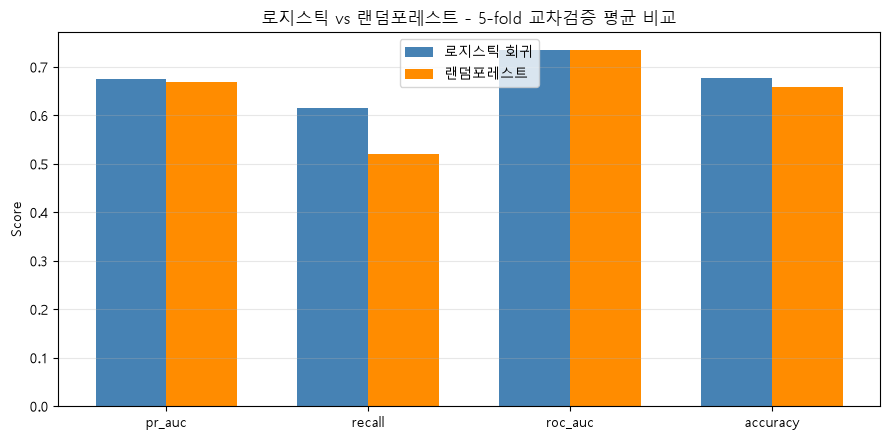

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(scoring))
width = 0.35

rf_means = [cv_results[f"test_{k}"].mean() for k in scoring]
lr_means = [0.674204, 0.614646, 0.734162, 0.677152]

ax.bar(x - width/2, lr_means, width, label="로지스틱 회귀", color="steelblue")
ax.bar(x + width/2, rf_means, width, label="랜덤포레스트", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(list(scoring.keys()))
ax.set_ylabel("Score")
ax.set_title("로지스틱 vs 랜덤포레스트 - 5-fold 교차검증 평균 비교")
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 4. Out-of-fold 예측 기반 분류 리포트 + 혼동행렬

In [6]:
y_pred = cross_val_predict(rf_model, X, y, cv=cv, method="predict")
y_proba = cross_val_predict(rf_model, X, y, cv=cv, method="predict_proba")[:, 1]

print("분류 리포트 (0=유지, 1=위축)")
print(classification_report(y, y_pred, target_names=["유지(0)", "위축(1)"]))

cm = confusion_matrix(y, y_pred)
print("혼동행렬")
print(pd.DataFrame(cm, index=["실제 유지", "실제 위축"], columns=["예측 유지", "예측 위축"]))


분류 리포트 (0=유지, 1=위축)
              precision    recall  f1-score   support

       유지(0)       0.67      0.77      0.71       276
       위축(1)       0.65      0.52      0.58       223

    accuracy                           0.66       499
   macro avg       0.66      0.65      0.65       499
weighted avg       0.66      0.66      0.65       499

혼동행렬
       예측 유지  예측 위축
실제 유지    213     63
실제 위축    107    116


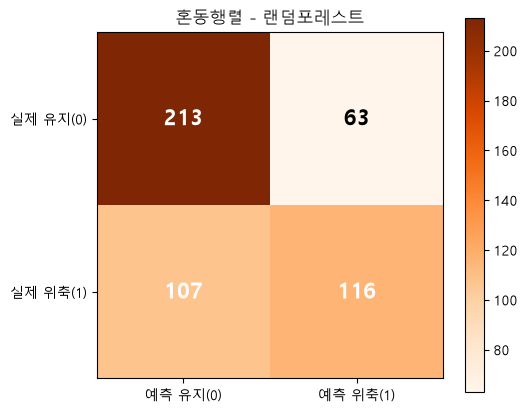

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Oranges")

labels_display = ["유지(0)", "위축(1)"]
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels([f"예측 {l}" for l in labels_display])
ax.set_yticklabels([f"실제 {l}" for l in labels_display])

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black",
                 fontsize=16, fontweight="bold")

ax.set_title("혼동행렬 - 랜덤포레스트")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


## 5. 전체 데이터로 최종 학습 (SHAP 해석용)

**주의**: 4번까지는 성능 "평가"용(fold별 검증 예측), 아래는 해석을 위해 전체 데이터로 재학습한 별도 모델.


In [8]:
rf_model.fit(X, y)
print("학습 완료")


학습 완료


## 6. SHAP 값 계산

`shap` 패키지가 없으면 설치: `pip install shap --break-system-packages`


In [9]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "shap", "--break-system-packages", "-q"])
    import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X)

# 이진분류에서 shap_values가 (n_samples, n_features, 2) 형태로 나오는 버전 대응
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]  # 클래스 1(위축) 기준
elif shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print(f"shap_values shape: {shap_values_pos.shape}")


c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap_values shape: (499, 18)


## 7. SHAP 요약 플롯 — 전역 feature 중요도 (막대)

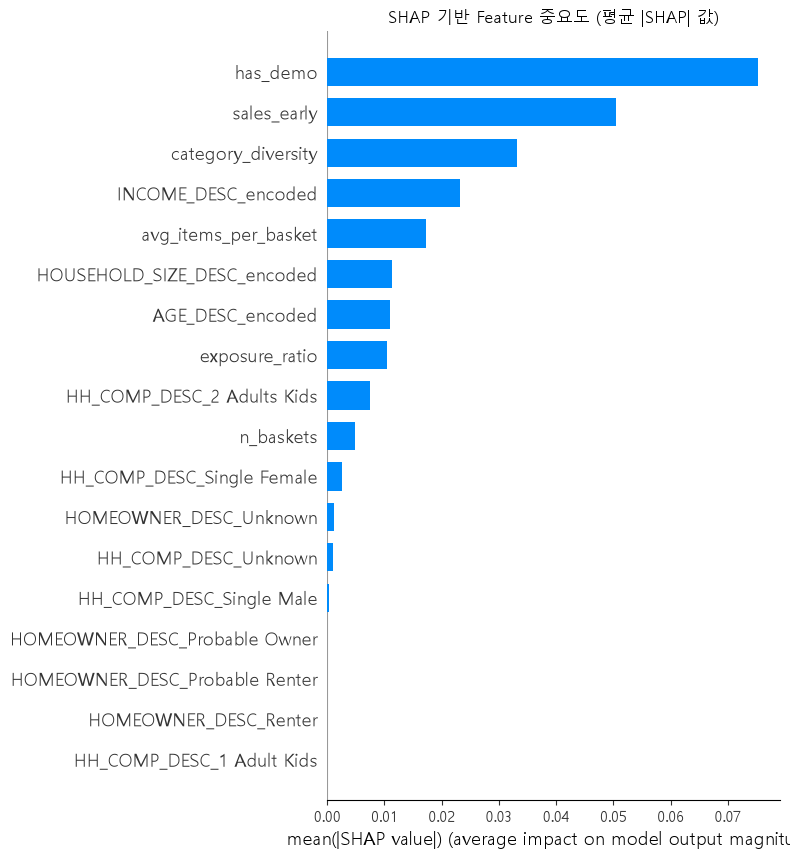

In [10]:
shap.summary_plot(shap_values_pos, X, plot_type="bar", show=False)
plt.title("SHAP 기반 Feature 중요도 (평균 |SHAP| 값)")
plt.tight_layout()
plt.show()


## 8. SHAP Beeswarm — 방향성까지 포함한 상세 분포

각 점은 가구 하나. 색은 feature 값의 크기(빨강=높음, 파랑=낮음), x축 위치는 그 가구의 위축(1) 예측에 대한 기여도.


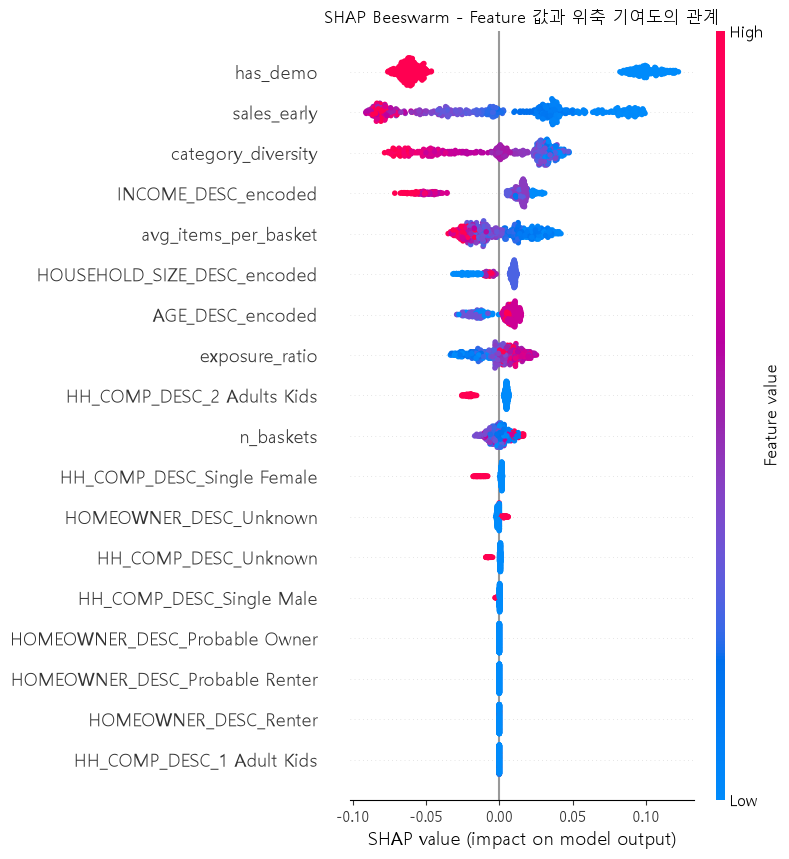

In [11]:
shap.summary_plot(shap_values_pos, X, show=False)
plt.title("SHAP Beeswarm - Feature 값과 위축 기여도의 관계")
plt.tight_layout()
plt.show()


## 9. 상위 3개 feature — Dependence Plot (비선형 관계 확인)

SHAP 중요도 상위 3개 feature에 대해, 값이 변할 때 위축 기여도(SHAP 값)가 선형으로 변하는지
아니면 특정 구간에서 급격히 꺾이는지 확인 — 이게 로지스틱(선형 가정)이 놓칠 수 있는 부분.


In [12]:
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top3_features = pd.Series(mean_abs_shap, index=feature_cols_final).sort_values(ascending=False).head(3)
print("SHAP 기준 상위 3개 feature")
print(top3_features)


SHAP 기준 상위 3개 feature
has_demo              0.075339
sales_early           0.050389
category_diversity    0.033213
dtype: float64


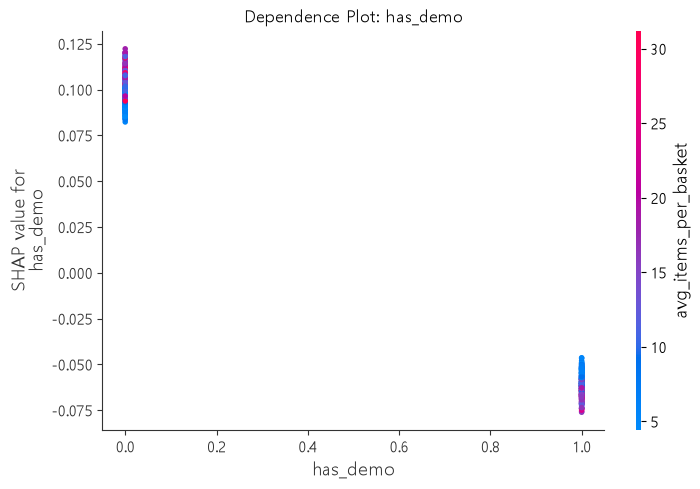

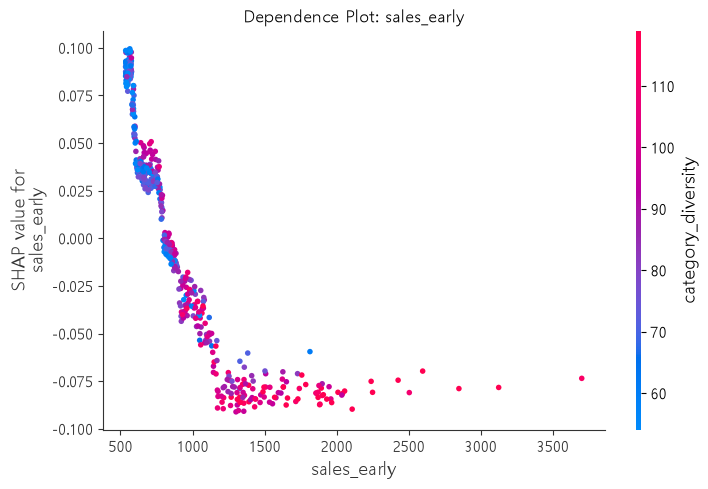

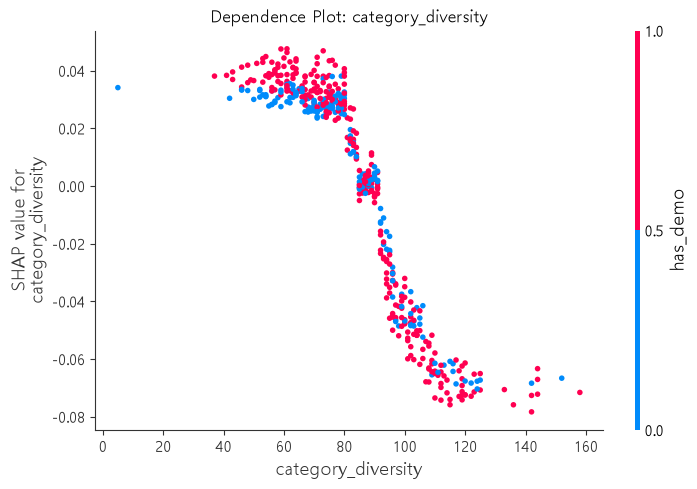

In [13]:
for feat in top3_features.index:
    shap.dependence_plot(feat, shap_values_pos, X, show=False)
    plt.title(f"Dependence Plot: {feat}")
    plt.tight_layout()
    plt.show()


## 10. 로지스틱 vs 랜덤포레스트 — 방향 비교표

로지스틱 오즈비(양수 계수=위험, 음수=보호)와 SHAP 평균 기여 방향이 일치하는지 확인.


In [14]:
# 각 feature의 SHAP 값 평균(부호 포함) - 양수면 위축 위험 방향, 음수면 보호 방향
mean_shap_signed = shap_values_pos.mean(axis=0)

comparison = pd.DataFrame({
    "feature": feature_cols_final,
    "mean_abs_shap": mean_abs_shap,
    "mean_signed_shap": mean_shap_signed,
    "rf_direction": np.where(mean_shap_signed > 0, "위험(위축↑)", "보호(위축↓)"),
}).sort_values("mean_abs_shap", ascending=False)

print(comparison.to_string(index=False))


                       feature  mean_abs_shap  mean_signed_shap rf_direction
                      has_demo       0.075339         -0.002771      보호(위축↓)
                   sales_early       0.050389         -0.000653      보호(위축↓)
            category_diversity       0.033213          0.000396      위험(위축↑)
           INCOME_DESC_encoded       0.023126          0.000680      위험(위축↑)
          avg_items_per_basket       0.017311          0.000071      위험(위축↑)
   HOUSEHOLD_SIZE_DESC_encoded       0.011243          0.000964      위험(위축↑)
              AGE_DESC_encoded       0.011015          0.000860      위험(위축↑)
                exposure_ratio       0.010413         -0.000140      보호(위축↓)
    HH_COMP_DESC_2 Adults Kids       0.007542          0.000688      위험(위축↑)
                     n_baskets       0.004911          0.000244      위험(위축↑)
    HH_COMP_DESC_Single Female       0.002561          0.000101      위험(위축↑)
        HOMEOWNER_DESC_Unknown       0.001146         -0.000295      보호(위축↓)

## 11. 해석 가이드

- **성능(4번 vs 로지스틱)**: 랜덤포레스트가 로지스틱보다 뚜렷하게 좋다면 비선형/상호작용이 실제로 존재한다는 뜻,
  비슷하거나 못하다면 이 데이터의 관계는 대체로 선형적이라는 뜻 (표본이 작아 트리가 유리하지 않을 수도 있음)
- **SHAP 중요도 순위**: 로지스틱 오즈비 순위와 대체로 일치하면 두 모델이 서로 결과를 재확인해준 것
- **방향 불일치가 있다면**: 특히 `exposure_ratio`처럼 로지스틱에서 거의 중립이었던 feature가 SHAP에서
  강하게 나온다면, 이는 다른 변수와의 **상호작용** 효과(예: 특정 소득구간에서만 노출이 위축과 관련있음)일 가능성
  → dependence plot에서 색상(다른 feature 값)에 따라 패턴이 갈리는지 확인
- **최종 결론 작성 시**: 두 모델이 공통으로 지목하는 feature(예: sales_early, category_diversity, has_demo)를
  핵심 신호로, 한쪽에서만 나오는 feature는 "표본 제약상 추가 검증이 필요한 탐색적 신호"로 구분해서 서술
